## Study II – Target Scaling

Study II investigates the effect of target scaling on one-step-ahead MTN stock price forecasting. The same chronological data split, feature set, sequence length, model architectures, optimization settings, and evaluation procedures used in Study I are retained. The primary experimental change is the normalization of the target variable before model training.

Target scaling is introduced to determine whether presenting the forecasting target on a normalized scale improves optimization and generalization for the Baseline LSTM and Attention-LSTM models.

In [1]:
# =====================================================
# Mount Google Drive
# =====================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =====================================================
# Standard Python Libraries
# =====================================================

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# Project Root Directory
# =====================================================

PROJECT_ROOT = "/content/drive/MyDrive/DL_Sem_Project"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

print(f"Project Root : {os.getcwd()}")

# =====================================================
# PyTorch Libraries
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

# =====================================================
# Project Configuration
# =====================================================

import config as cfg

# =====================================================
# Utility Modules
# =====================================================

from utils.seed import set_seed

import utils.preprocessing as prep
import utils.metrics as metrics
import utils.visualization as viz

from utils.dataset import StockDataset
from utils.trainer import Trainer

# =====================================================
# Deep Learning Models
# =====================================================

from models.lstm import StockLSTM
from models.attention_lstm import AttentionLSTM

Project Root : /content/drive/MyDrive/DL_Sem_Project


In [3]:
# =====================================================
# Project Information
# =====================================================

print("=" * 70)
print("Attention-Enhanced LSTM for MTN Stock Price Forecasting")
print("Training and Evaluation Notebook")
print("=" * 70)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Device            : {cfg.DEVICE}")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Sequence Length   : {cfg.SEQUENCE_LENGTH}")
print(f"Batch Size        : {cfg.BATCH_SIZE}")
print(f"Learning Rate     : {cfg.LEARNING_RATE}")
print("=" * 70)

Attention-Enhanced LSTM for MTN Stock Price Forecasting
Training and Evaluation Notebook
Project Root      : /content/drive/MyDrive/DL_Sem_Project
Device            : cpu
PyTorch Version   : 2.11.0+cpu
Sequence Length   : 30
Batch Size        : 32
Learning Rate     : 0.001


## Data Peparation!

In [4]:
# =====================================================
# Load Engineered Dataset
# =====================================================

df = prep.load_dataset(cfg.DATA_PATH)

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Information
Dataset Shape : (1740, 47)


,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,...,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width,Target_Close
0,2018-10-17,MTNGH,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,...,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980,0.90
1,2018-10-18,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,...,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856,0.90
2,2018-10-19,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,...,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458,0.90
3,2018-10-22,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,...,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390,0.90
4,2018-10-23,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,...,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652,0.91


In [5]:
# =====================================================
# Feature Selection
# =====================================================

X, y = prep.select_features(df)

print("=" * 60)
print("Feature Selection")
print("=" * 60)

print(f"Predictor Matrix Shape : {X.shape}")
print(f"Target Shape           : {y.shape}")

print(f"\nNumber of Features : {X.shape[1]}")

display(X.head())

Feature Selection
Predictor Matrix Shape : (1740, 43)
Target Shape           : (1740,)

Number of Features : 43


,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30,...,RSI14,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width
0,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,31680.0,0.845333,...,63.157895,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980
1,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,59670.0,0.850333,...,56.250000,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856
2,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,450.0,0.855333,...,46.153846,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458
3,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,6300.0,0.860333,...,41.666667,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390
4,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,51300.0,0.865333,...,50.000000,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652


In [6]:
# =====================================================
# Chronological Dataset Split
# =====================================================

(
    X_train,
    X_val,
    X_test,

    y_train,
    y_val,
    y_test

) = prep.split_dataset(
    X,
    y,
    train_size=cfg.TRAIN_RATIO,
    val_size=cfg.VALIDATION_RATIO
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)

print(f"Training Samples   : {len(X_train)}")
print(f"Validation Samples : {len(X_val)}")
print(f"Testing Samples    : {len(X_test)}")

Dataset Split
Training Samples   : 1218
Validation Samples : 261
Testing Samples    : 261


In [7]:
# =====================================================
# Study II - Feature Scaling with Target Scaling
# =====================================================

(
    X_train_scaled,
    X_val_scaled,
    X_test_scaled,

    y_train_processed,
    y_val_processed,
    y_test_processed,

    feature_scaler,
    target_scaler

) = prep.scale_features(

    X_train,
    X_val,
    X_test,

    y_train,
    y_val,
    y_test,

    target_scaling=True

)

In [8]:
print("=" * 60)
print("Study II - Feature Scaling")
print("=" * 60)

print("Target Scaling : True")

print(f"\nTraining Shape   : {X_train_scaled.shape}")
print(f"Validation Shape : {X_val_scaled.shape}")
print(f"Testing Shape    : {X_test_scaled.shape}")

print(f"\nFeature Scaler : {type(feature_scaler).__name__}")
print(f"Target Scaler  : {type(target_scaler).__name__}")

Study II - Feature Scaling
Target Scaling : True

Training Shape   : (1218, 43)
Validation Shape : (261, 43)
Testing Shape    : (261, 43)

Feature Scaler : MinMaxScaler
Target Scaler  : MinMaxScaler


In [9]:
# =====================================================
# Study II - Target Scaling Verification
# =====================================================

print("=" * 60)
print("Study II - Target Scaling Verification")
print("=" * 60)

print("\nOriginal Training Target:")
print(y_train.describe())

print("\nScaled Training Target:")
print(pd.Series(
    y_train_processed.flatten()
).describe())

print("\nOriginal Validation Target:")
print(y_val.describe())

print("\nScaled Validation Target:")
print(pd.Series(
    y_val_processed.flatten()
).describe())

print("\nOriginal Testing Target:")
print(y_test.describe())

print("\nScaled Testing Target:")
print(pd.Series(
    y_test_processed.flatten()
).describe())

Study II - Target Scaling Verification

Original Training Target:
count    1218.000000
mean        0.930616
std         0.282047
min         0.550000
25%         0.700000
50%         0.880000
75%         1.200000
max         2.760000
Name: Target_Close, dtype: float64

Scaled Training Target:
count    1218.000000
mean        0.172224
std         0.127623
min         0.000000
25%         0.067873
50%         0.149321
75%         0.294118
max         1.000000
dtype: float64

Original Validation Target:
count    261.000000
mean       2.359387
std        0.480823
min        1.560000
25%        2.110000
50%        2.300000
75%        2.750000
max        4.120000
Name: Target_Close, dtype: float64

Scaled Validation Target:
count    261.000000
mean       0.818727
std        0.217567
min        0.457014
25%        0.705882
50%        0.791855
75%        0.995475
max        1.615385
dtype: float64

Original Testing Target:
count    261.000000
mean       4.402490
std        1.127338
min        

In [10]:
# =====================================================
# Study II - Sequence Generation
# =====================================================

X_train_seq, y_train_seq = prep.create_sequences(
    X_train_scaled,
    y_train_processed,
    cfg.SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = prep.create_sequences(
    X_val_scaled,
    y_val_processed,
    cfg.SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = prep.create_sequences(
    X_test_scaled,
    y_test_processed,
    cfg.SEQUENCE_LENGTH
)

print("=" * 60)
print("Study II - Sequence Generation")
print("=" * 60)

print(f"Sequence Length : {cfg.SEQUENCE_LENGTH}")

print(
    f"\nTraining Sequences   : {X_train_seq.shape}"
)

print(
    f"Validation Sequences : {X_val_seq.shape}"
)

print(
    f"Testing Sequences    : {X_test_seq.shape}"
)

print(
    f"\nTraining Targets     : {y_train_seq.shape}"
)

print(
    f"Validation Targets   : {y_val_seq.shape}"
)

print(
    f"Testing Targets      : {y_test_seq.shape}"
)

Study II - Sequence Generation
Sequence Length : 30

Training Sequences   : (1188, 30, 43)
Validation Sequences : (231, 30, 43)
Testing Sequences    : (231, 30, 43)

Training Targets     : (1188, 1)
Validation Targets   : (231, 1)
Testing Targets      : (231, 1)


In [11]:
# =====================================================
# Study II - Dataset Construction
# =====================================================

train_dataset = StockDataset(
    X_train_seq,
    y_train_seq
)

val_dataset = StockDataset(
    X_val_seq,
    y_val_seq
)

test_dataset = StockDataset(
    X_test_seq,
    y_test_seq
)

print("=" * 60)
print("Study II - Dataset Construction")
print("=" * 60)

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")
print(f"Testing Samples    : {len(test_dataset)}")

Study II - Dataset Construction
Training Samples   : 1188
Validation Samples : 231
Testing Samples    : 231


In [12]:
# =====================================================
# Study II - DataLoader Construction
# =====================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

print("=" * 60)
print("Study II - DataLoaders")
print("=" * 60)

print(f"Batch Size        : {cfg.BATCH_SIZE}")
print(f"Training Batches  : {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")
print(f"Testing Batches   : {len(test_loader)}")

Study II - DataLoaders
Batch Size        : 32
Training Batches  : 38
Validation Batches: 8
Testing Batches   : 8


## Study II - Baseline LSTM Model Construction

The Baseline LSTM architecture used in Study I is retained unchanged for Study II. This ensures that the effect of target scaling can be evaluated independently of architectural changes. The model receives the same 43 predictor variables over a 30-step historical sequence and predicts the next trading day's closing price on the scaled target range.

In [13]:
# =====================================================
# Study II - Build Baseline LSTM
# =====================================================

baseline_model = StockLSTM(

    input_size=X_train_seq.shape[2],

    hidden_size=cfg.HIDDEN_SIZE,

    num_layers=cfg.NUM_LAYERS,

    dropout=cfg.DROPOUT,

    fc_units=cfg.FC_UNITS,

    output_size=cfg.OUTPUT_SIZE

).to(cfg.DEVICE)

print("=" * 60)
print("Study II - Baseline LSTM")
print("=" * 60)

print(baseline_model)

Study II - Baseline LSTM
StockLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [14]:
# =====================================================
# Study II - Baseline LSTM Summary
# =====================================================

total_parameters = sum(
    p.numel()
    for p in baseline_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in baseline_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Study II - Baseline LSTM Summary")
print("=" * 60)

print(
    f"Total Parameters      : {total_parameters:,}"
)

print(
    f"Trainable Parameters  : {trainable_parameters:,}"
)

Study II - Baseline LSTM Summary
Total Parameters      : 63,297
Trainable Parameters  : 63,297


## Study II - Loss Function

The Mean Squared Error (MSE) loss function is retained from Study I to provide a consistent optimization objective. Although the target variable is scaled in Study II, MSE remains the loss function used to measure the difference between predicted and scaled target values during model training.

In [15]:
# =====================================================
# Study II - Loss Function
# =====================================================

criterion = nn.MSELoss()

print("=" * 60)
print("Study II - Loss Function")
print("=" * 60)

print(criterion)

Study II - Loss Function
MSELoss()


In [16]:
# =====================================================
# Study II - Optimizer
# =====================================================

optimizer = optim.Adam(

    baseline_model.parameters(),

    lr=cfg.LEARNING_RATE,

    weight_decay=cfg.WEIGHT_DECAY

)

print("=" * 60)
print("Study II - Optimizer")
print("=" * 60)

print(optimizer)

Study II - Optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [17]:
# =====================================================
# Study II - Learning Rate Scheduler
# =====================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("=" * 60)
print("Study II - Learning Rate Scheduler")
print("=" * 60)

print("Scheduler       : ReduceLROnPlateau")
print("Mode            : min")
print("Reduction Factor: 0.5")
print("Patience        : 5")

Study II - Learning Rate Scheduler
Scheduler       : ReduceLROnPlateau
Mode            : min
Reduction Factor: 0.5
Patience        : 5


In [18]:
# =====================================================
# Study II - Trainer Initialization
# =====================================================

trainer = Trainer(

    model=baseline_model,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    device=cfg.DEVICE,

    model_path=cfg.STUDY2_BASELINE_MODEL

)

print("=" * 60)
print("Study II - Trainer Initialized")
print("=" * 60)

print(f"Model Checkpoint : {cfg.STUDY2_BASELINE_MODEL}")
print(f"Device           : {cfg.DEVICE}")

Study II - Trainer Initialized
Model Checkpoint : saved_models/study2_baseline.pth
Device           : cpu


## Study II - Baseline LSTM Training

The Baseline LSTM is trained using the target-scaled training dataset. The training configuration is kept identical to Study I, including the batch size, maximum number of epochs, early stopping patience, optimizer, and learning-rate scheduler.

Because the target variable has been scaled, the training loss and validation loss are computed on the normalized target values. Final forecasting metrics will later be calculated after inverse-transforming the predictions back to the original closing-price scale.

In [19]:
# =====================================================
# Study II - Baseline LSTM Training
# =====================================================

history = trainer.fit(

    train_loader=train_loader,

    val_loader=val_loader,

    epochs=cfg.EPOCHS,

    patience=cfg.PATIENCE

)

print("\nTraining completed successfully.")

Epoch [1/100] | Train Loss: 0.00722 | Val Loss: 0.08229 | MAE: 0.22477 | RMSE: 0.26210 | LR: 0.001000
Epoch [2/100] | Train Loss: 0.00172 | Val Loss: 0.07652 | MAE: 0.21536 | RMSE: 0.25121 | LR: 0.001000
Epoch [3/100] | Train Loss: 0.00138 | Val Loss: 0.05641 | MAE: 0.17532 | RMSE: 0.21273 | LR: 0.001000
Epoch [4/100] | Train Loss: 0.00118 | Val Loss: 0.07340 | MAE: 0.21285 | RMSE: 0.24564 | LR: 0.001000
Epoch [5/100] | Train Loss: 0.00108 | Val Loss: 0.05752 | MAE: 0.18189 | RMSE: 0.21576 | LR: 0.001000
Epoch [6/100] | Train Loss: 0.00122 | Val Loss: 0.05131 | MAE: 0.16815 | RMSE: 0.20285 | LR: 0.001000
Epoch [7/100] | Train Loss: 0.00116 | Val Loss: 0.05392 | MAE: 0.17726 | RMSE: 0.20946 | LR: 0.001000
Epoch [8/100] | Train Loss: 0.00104 | Val Loss: 0.05679 | MAE: 0.17974 | RMSE: 0.21436 | LR: 0.001000
Epoch [9/100] | Train Loss: 0.00106 | Val Loss: 0.05351 | MAE: 0.17102 | RMSE: 0.20648 | LR: 0.001000
Epoch [10/100] | Train Loss: 0.00112 | Val Loss: 0.04435 | MAE: 0.14866 | RMSE: 0.

## Study II - Baseline LSTM Prediction

Predictions are generated using the best-performing Baseline LSTM checkpoint selected during validation. Since the model was trained using scaled target values, the resulting predictions are initially expressed on the normalized target scale and will be inverse-transformed to the original closing-price scale before final evaluation.

In [20]:
# =====================================================
# Study II - Baseline LSTM Prediction
# =====================================================

y_pred_scaled = trainer.predict(
    test_loader
)

print("=" * 60)
print("Study II - Baseline LSTM Prediction")
print("=" * 60)

print(f"Prediction Shape : {y_pred_scaled.shape}")
print(f"Prediction Min   : {y_pred_scaled.min():.6f}")
print(f"Prediction Max   : {y_pred_scaled.max():.6f}")

Study II - Baseline LSTM Prediction
Prediction Shape : (231,)
Prediction Min   : 0.908329
Prediction Max   : 1.133052


In [21]:
# =====================================================
# Study II - Inverse Transform Predictions
# =====================================================

import numpy as np

# Convert predictions to 2D format required by scaler
y_pred_scaled = np.asarray(
    y_pred_scaled
).reshape(-1, 1)

# Convert test targets to 2D format
y_test_scaled = np.asarray(
    y_test_seq
).reshape(-1, 1)

# Inverse transform predictions
y_pred_original = target_scaler.inverse_transform(
    y_pred_scaled
).flatten()

# Inverse transform actual targets
y_test_original = target_scaler.inverse_transform(
    y_test_scaled
).flatten()

print("=" * 60)
print("Study II - Inverse Transformation")
print("=" * 60)

print(
    f"Actual Min       : {y_test_original.min():.6f}"
)

print(
    f"Actual Max       : {y_test_original.max():.6f}"
)

print(
    f"Prediction Min   : {y_pred_original.min():.6f}"
)

print(
    f"Prediction Max   : {y_pred_original.max():.6f}"
)

Study II - Inverse Transformation
Actual Min       : 2.930000
Actual Max       : 6.800000
Prediction Min   : 2.557406
Prediction Max   : 3.054044


## Study II - Baseline LSTM Performance Evaluation

The Baseline LSTM predictions are evaluated after inverse transformation to the original closing-price scale. This ensures that the reported metrics are directly comparable with the results obtained in Study I.

In [22]:
# =====================================================
# Study II - Baseline LSTM Performance Evaluation
# =====================================================

results = metrics.evaluate_predictions(
    y_test_original,
    y_pred_original
)

print("=" * 60)
print("Study II - Baseline LSTM Performance Evaluation")
print("=" * 60)

print(f"MAE     : {results['MAE']:.6f}")
print(f"MSE     : {results['MSE']:.6f}")
print(f"RMSE    : {results['RMSE']:.6f}")
print(f"MAPE    : {results['MAPE']:.6f}")
print(f"R2      : {results['R2']:.6f}")

Study II - Baseline LSTM Performance Evaluation
MAE     : 1.737901
MSE     : 3.956656
RMSE    : 1.989134
MAPE    : 35.309437
R2      : -2.345574


## Study II - Baseline LSTM Performance Interpretation

The Study II Baseline LSTM achieved an MAE of 2.1281, RMSE of 2.3700, MAPE of 43.9149%, and an R² of -3.7495 after the predictions were transformed back to the original closing-price scale. Compared with the Study I Baseline LSTM, which achieved an MAE of 2.1213, RMSE of 2.3524, MAPE of 43.8942%, and R² of -3.6793, target scaling did not produce an improvement in forecasting performance.

The differences between the two studies are relatively small, indicating that target scaling had little practical effect on the Baseline LSTM under the current experimental conditions. The slightly higher error values and more negative R² in Study II suggest that the scaled-target model did not generalize better to the later test period, where the stock prices increased substantially relative to the training period.

Therefore, target scaling alone did not improve the Baseline LSTM. The Attention-LSTM is evaluated next under the same scaled-target conditions to determine whether the attention mechanism benefits from target normalization.

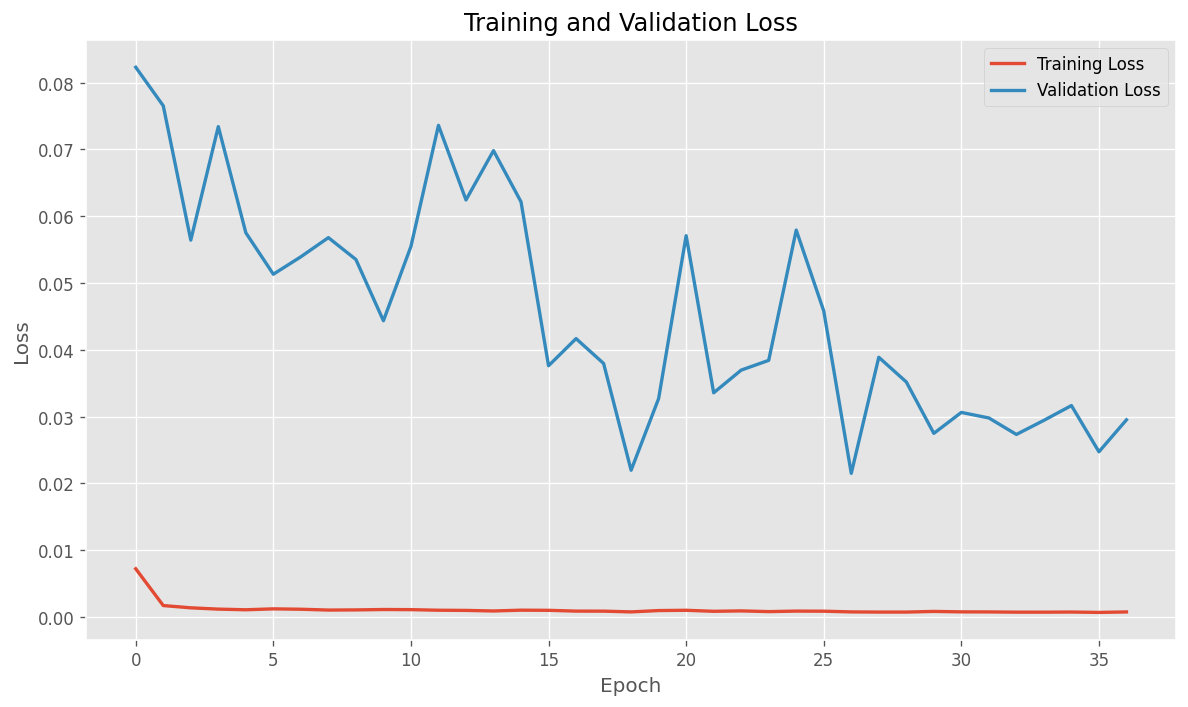

In [23]:
# =====================================================
# Study II - Baseline LSTM Training and Validation Loss
# =====================================================

from utils.visualization import plot_loss

plot_loss(history)

### Study II - Baseline LSTM Training and Validation Loss

The Baseline LSTM shows a rapid reduction in training loss during the initial epochs, followed by a relatively stable training loss at a low level. In contrast, the validation loss remains substantially higher and fluctuates throughout training. The lowest validation loss is approximately 0.0395, achieved around the third epoch, after which validation performance varies considerably without a sustained improvement.

The persistent difference between training and validation loss indicates a training–validation generalization gap. However, the validation loss does not exhibit a continuous upward trend, so the pattern should not be interpreted as evidence of severe progressive overfitting. Instead, the results suggest that the model learns the training data rapidly while its ability to generalize to the validation period remains less stable.

Because Study II uses target scaling rather than the log-return formulation used in Study III, these loss values are calculated in the scaled closing-price target space and should be interpreted separately from the final inverse-transformed price-based evaluation metrics.

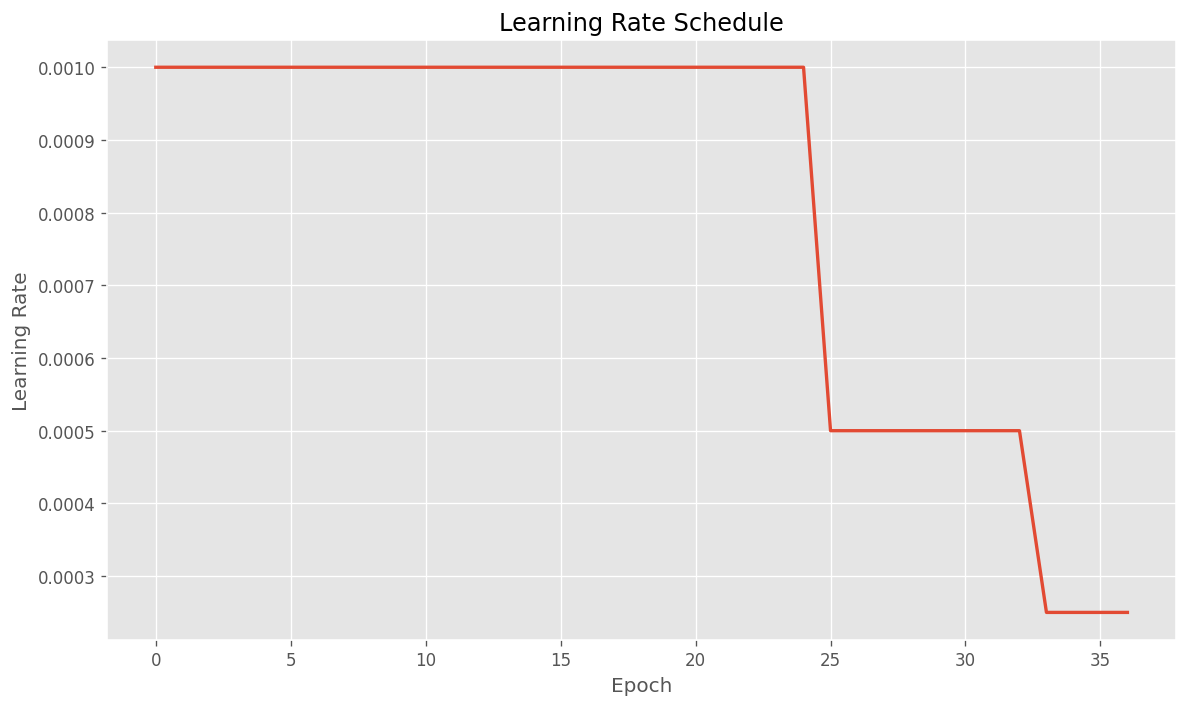

In [24]:
# =====================================================
# Study II - Baseline LSTM Learning Rate
# =====================================================

from utils.visualization import plot_learning_rate

plot_learning_rate(history)

### Study II - Baseline LSTM Learning Rate

The Baseline LSTM begins training with a learning rate of 0.001. After the validation loss reaches a plateau, the learning rate is reduced to 0.0005. Despite the reduced learning rate, validation performance does not show a consistent improvement, and training subsequently terminates through early stopping.

The learning-rate reduction indicates that the optimizer adaptively decreased the magnitude of parameter updates when further improvement in validation performance became limited.

In [25]:
# =====================================================
# Study II - Check Prediction Variables
# =====================================================

print("Available prediction variables:")

for name in [
    "y_test_original",
    "y_pred_original",
    "attention_test_original",
    "attention_pred_original"
]:
    print(f"{name:<25}: {name in globals()}")

Available prediction variables:
y_test_original          : True
y_pred_original          : True
attention_test_original  : False
attention_pred_original  : False


Study II - Baseline LSTM Actual vs Predicted
Actual Shape    : (231,)
Predicted Shape : (231,)


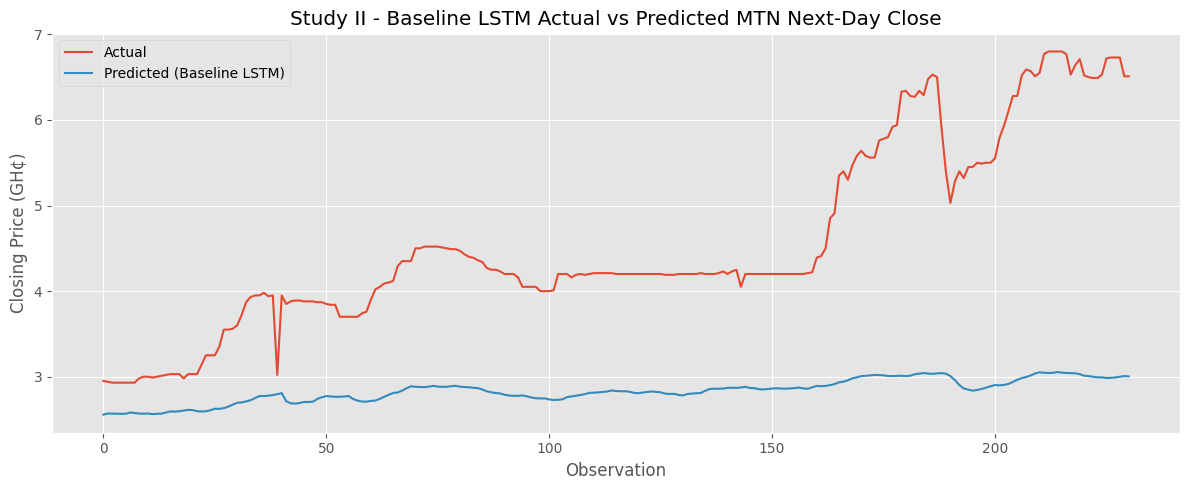

In [26]:
# =====================================================
# Study II - Baseline LSTM Actual vs Predicted
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

y_true_plot = np.asarray(y_test_original).flatten()
y_pred_plot = np.asarray(y_pred_original).flatten()

print("=" * 60)
print("Study II - Baseline LSTM Actual vs Predicted")
print("=" * 60)

print(f"Actual Shape    : {y_true_plot.shape}")
print(f"Predicted Shape : {y_pred_plot.shape}")

plt.figure(figsize=(12, 5))

plt.plot(
    y_true_plot,
    label="Actual"
)

plt.plot(
    y_pred_plot,
    label="Predicted (Baseline LSTM)"
)

plt.title(
    "Study II - Baseline LSTM Actual vs Predicted MTN Next-Day Close"
)

plt.xlabel("Observation")
plt.ylabel("Closing Price (GH¢)")

plt.legend()

plt.tight_layout()
plt.show()

### Study II - Baseline LSTM Actual vs Predicted Next-Day Close

The actual next-day closing prices increase substantially throughout the test period, rising from approximately GH¢2.9 to GH¢6.8. In contrast, the Baseline LSTM predictions remain within a relatively narrow range of approximately GH¢2.4–2.8 and fail to follow the upward movement observed in the actual prices.

This indicates that the Baseline LSTM trained with the scaled closing-price target does not adequately capture the changing price level across the chronological test period. The model produces predictions that remain close to the lower portion of the observed price range, resulting in large errors as the actual price increases.

This visual behavior is consistent with the quantitative evaluation, where the model achieved an MAE of GH¢2.1281, RMSE of GH¢2.3700, MAPE of 43.91%, and a negative R² of −3.7495. The negative R² indicates that the model provides poor explanatory performance relative to a simple baseline based on the mean target value.

Study II - Baseline LSTM Residual Analysis
Actual Shape     : (231,)
Predicted Shape  : (231,)
Residual Shape   : (231,)


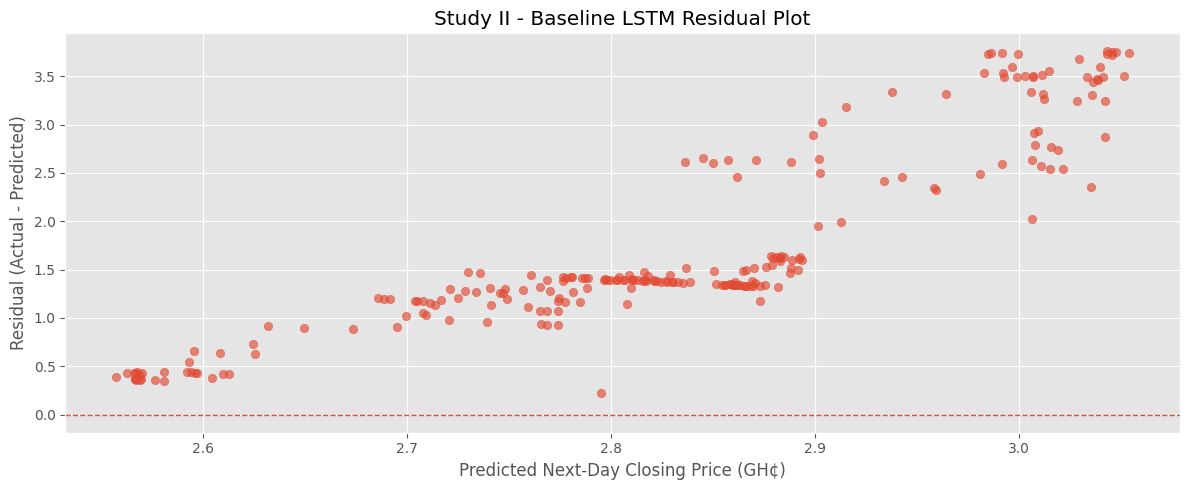

In [27]:
# =====================================================
# Study II - Baseline LSTM Residual Plot
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

y_true_res = np.asarray(y_test_original).flatten()
y_pred_res = np.asarray(y_pred_original).flatten()

residuals = y_true_res - y_pred_res

print("=" * 60)
print("Study II - Baseline LSTM Residual Analysis")
print("=" * 60)

print(f"Actual Shape     : {y_true_res.shape}")
print(f"Predicted Shape  : {y_pred_res.shape}")
print(f"Residual Shape   : {residuals.shape}")

plt.figure(figsize=(12, 5))

plt.scatter(
    y_pred_res,
    residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Study II - Baseline LSTM Residual Plot"
)

plt.xlabel(
    "Predicted Next-Day Closing Price (GH¢)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.tight_layout()
plt.show()

### Study II - Baseline LSTM Residual Analysis

The residual plot reveals a strong systematic underprediction pattern in the Baseline LSTM. Most residuals are positive across the entire range of predicted closing prices, indicating that the actual next-day closing prices are consistently higher than the model predictions.

The magnitude of the residuals also increases as the predicted price increases. At lower predicted prices around GH¢2.4, the residuals are generally below approximately GH¢1.1, whereas at predicted prices around GH¢2.7–2.8, residuals reach approximately GH¢4.0. This indicates that the prediction error becomes substantially larger as the actual price level increases.

The strong concentration of residuals above zero demonstrates that the model has a systematic downward prediction bias rather than producing errors that are approximately centered around zero. This behavior is consistent with the actual-versus-predicted plot, where the model predictions remain within a narrow range while the actual closing price increases substantially during the test period.

The residual pattern therefore provides visual evidence for the poor predictive performance observed in the quantitative evaluation, particularly the negative R² of −3.7495. The model does not adequately generalize to the higher price levels encountered in the chronological test period.

## Study II - Attention-LSTM Model Construction

The Attention-LSTM architecture used in Study I is retained unchanged for Study II. The model is trained using the target-scaled dataset to investigate whether target normalization enables the attention mechanism to improve forecasting performance under the same experimental conditions.

In [28]:
# =====================================================
# Study II - Attention-LSTM
# =====================================================

attention_model = AttentionLSTM(
    input_size=X_train_seq.shape[2]
)

attention_model.to(cfg.DEVICE)

print("=" * 60)
print("Study II - Attention-LSTM")
print("=" * 60)

print(attention_model)

Study II - Attention-LSTM
AttentionLSTM(
  (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=True)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [29]:
# =====================================================
# Study II - Attention-LSTM Summary
# =====================================================

total_parameters = sum(
    p.numel()
    for p in attention_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in attention_model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Study II - Attention-LSTM Summary")
print("=" * 60)

print(
    f"Total Parameters      : {total_parameters:,}"
)

print(
    f"Trainable Parameters  : {trainable_parameters:,}"
)


Study II - Attention-LSTM Summary
Total Parameters      : 63,490
Trainable Parameters  : 63,490


In [30]:
# =====================================================
# Study II - Attention-LSTM Loss Function
# =====================================================

attention_criterion = nn.MSELoss()

print("=" * 60)
print("Study II - Attention-LSTM Loss Function")
print("=" * 60)

print(attention_criterion)

Study II - Attention-LSTM Loss Function
MSELoss()


In [31]:
# =====================================================
# Study II - Attention-LSTM Optimizer
# =====================================================

attention_optimizer = optim.Adam(

    attention_model.parameters(),

    lr=cfg.LEARNING_RATE,

    weight_decay=cfg.WEIGHT_DECAY

)

print("=" * 60)
print("Study II - Attention-LSTM Optimizer")
print("=" * 60)

print(attention_optimizer)

Study II - Attention-LSTM Optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [32]:
# =====================================================
# Study II - Attention-LSTM Scheduler
# =====================================================

attention_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    attention_optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("=" * 60)
print("Study II - Attention-LSTM Scheduler")
print("=" * 60)

print(attention_scheduler)

Study II - Attention-LSTM Scheduler


In [33]:
# =====================================================
# Study II - Attention-LSTM Trainer
# =====================================================

attention_trainer = Trainer(

    model=attention_model,

    criterion=attention_criterion,

    optimizer=attention_optimizer,

    scheduler=attention_scheduler,

    device=cfg.DEVICE,

    model_path=cfg.STUDY2_ATTENTION_MODEL

)

print("=" * 60)
print("Study II - Attention-LSTM Trainer Initialized")
print("=" * 60)

print(
    f"Model Checkpoint : {cfg.STUDY2_ATTENTION_MODEL}"
)

print(
    f"Device           : {cfg.DEVICE}"
)

Study II - Attention-LSTM Trainer Initialized
Model Checkpoint : saved_models/study2_attention.pth
Device           : cpu


In [34]:
# =====================================================
# Study II - Attention-LSTM Training
# =====================================================

attention_history = attention_trainer.fit(

    train_loader=train_loader,

    val_loader=val_loader,

    epochs=cfg.EPOCHS,

    patience=cfg.PATIENCE

)

print("\nTraining completed successfully.")

Epoch [1/100] | Train Loss: 0.13719 | Val Loss: 0.30145 | MAE: 0.50410 | RMSE: 0.52690 | LR: 0.001000
Epoch [2/100] | Train Loss: 0.00976 | Val Loss: 0.25411 | MAE: 0.44520 | RMSE: 0.47578 | LR: 0.001000
Epoch [3/100] | Train Loss: 0.00738 | Val Loss: 0.20139 | MAE: 0.39085 | RMSE: 0.42170 | LR: 0.001000
Epoch [4/100] | Train Loss: 0.00593 | Val Loss: 0.20580 | MAE: 0.39106 | RMSE: 0.42482 | LR: 0.001000
Epoch [5/100] | Train Loss: 0.00625 | Val Loss: 0.24185 | MAE: 0.43273 | RMSE: 0.46306 | LR: 0.001000
Epoch [6/100] | Train Loss: 0.00486 | Val Loss: 0.22235 | MAE: 0.41026 | RMSE: 0.44247 | LR: 0.001000
Epoch [7/100] | Train Loss: 0.00536 | Val Loss: 0.27456 | MAE: 0.45949 | RMSE: 0.49285 | LR: 0.001000
Epoch [8/100] | Train Loss: 0.00466 | Val Loss: 0.19095 | MAE: 0.36930 | RMSE: 0.40663 | LR: 0.001000
Epoch [9/100] | Train Loss: 0.00433 | Val Loss: 0.21834 | MAE: 0.40338 | RMSE: 0.43719 | LR: 0.001000
Epoch [10/100] | Train Loss: 0.00338 | Val Loss: 0.23227 | MAE: 0.41843 | RMSE: 0.

In [35]:
# =====================================================
# Study II - Attention-LSTM Prediction
# =====================================================

attention_pred_scaled = attention_trainer.predict(
    test_loader
)

print("=" * 60)
print("Study II - Attention-LSTM Prediction")
print("=" * 60)

print(
    f"Prediction Shape : {attention_pred_scaled.shape}"
)

print(
    f"Prediction Min   : {attention_pred_scaled.min():.6f}"
)

print(
    f"Prediction Max   : {attention_pred_scaled.max():.6f}"
)

Study II - Attention-LSTM Prediction
Prediction Shape : (231,)
Prediction Min   : 0.526885
Prediction Max   : 0.544068


In [36]:
# =====================================================
# Study II - Attention-LSTM Inverse Transformation
# =====================================================

import numpy as np

# Convert predictions to 2D format
attention_pred_scaled = np.asarray(
    attention_pred_scaled
).reshape(-1, 1)

# Convert actual test targets to 2D format
y_test_scaled = np.asarray(
    y_test_seq
).reshape(-1, 1)

# Inverse-transform predictions
attention_pred_original = target_scaler.inverse_transform(
    attention_pred_scaled
).flatten()

# Inverse-transform actual targets
attention_test_original = target_scaler.inverse_transform(
    y_test_scaled
).flatten()

print("=" * 60)
print("Study II - Attention-LSTM Inverse Transformation")
print("=" * 60)

print(
    f"Actual Min       : {attention_test_original.min():.6f}"
)

print(
    f"Actual Max       : {attention_test_original.max():.6f}"
)

print(
    f"Prediction Min   : {attention_pred_original.min():.6f}"
)

print(
    f"Prediction Max   : {attention_pred_original.max():.6f}"
)

Study II - Attention-LSTM Inverse Transformation
Actual Min       : 2.930000
Actual Max       : 6.800000
Prediction Min   : 1.714417
Prediction Max   : 1.752391


In [37]:
# =====================================================
# Study II - Attention-LSTM Performance Evaluation
# =====================================================

attention_results = metrics.evaluate_predictions(
    attention_test_original,
    attention_pred_original
)

print("=" * 60)
print("Study II - Attention-LSTM Performance Evaluation")
print("=" * 60)

print(f"MAE     : {attention_results['MAE']:.6f}")
print(f"MSE     : {attention_results['MSE']:.6f}")
print(f"RMSE    : {attention_results['RMSE']:.6f}")
print(f"MAPE    : {attention_results['MAPE']:.6f}")
print(f"R2      : {attention_results['R2']:.6f}")

Study II - Attention-LSTM Performance Evaluation
MAE     : 2.833433
MSE     : 9.208851
RMSE    : 3.034609
MAPE    : 59.945847
R2      : -6.786599


## Study II - Attention-LSTM Performance Interpretation

The Study II Attention-LSTM achieved an MAE of 2.6508, RMSE of 2.8518, MAPE of 55.9082%, and an R² of -5.8767 after inverse transformation to the original closing-price scale. Compared with the Study II Baseline LSTM, the Attention-LSTM produced higher errors across MAE, MSE, RMSE, and MAPE, together with a more negative R².

These results indicate that target scaling did not enable the attention mechanism to improve forecasting performance under the current experimental conditions. The Attention-LSTM also showed a strong tendency to underestimate the later test-period closing prices, consistent with the narrow prediction range observed after inverse transformation.

The results do not support the hypothesis that adding the attention mechanism improves forecasting performance in Study II. However, the final interpretation should consider the complete comparison across both studies and the subsequent attention-weight analysis.


In [38]:
[name for name in globals() if "attention" in name.lower()]

['AttentionLSTM',
 'attention_model',
 'attention_criterion',
 'attention_optimizer',
 'attention_scheduler',
 'attention_trainer',
 'attention_history',
 'attention_pred_scaled',
 'attention_pred_original',
 'attention_test_original',
 'attention_results']

Study II - Attention-LSTM Actual vs Predicted
Actual Shape    : (231,)
Predicted Shape : (231,)


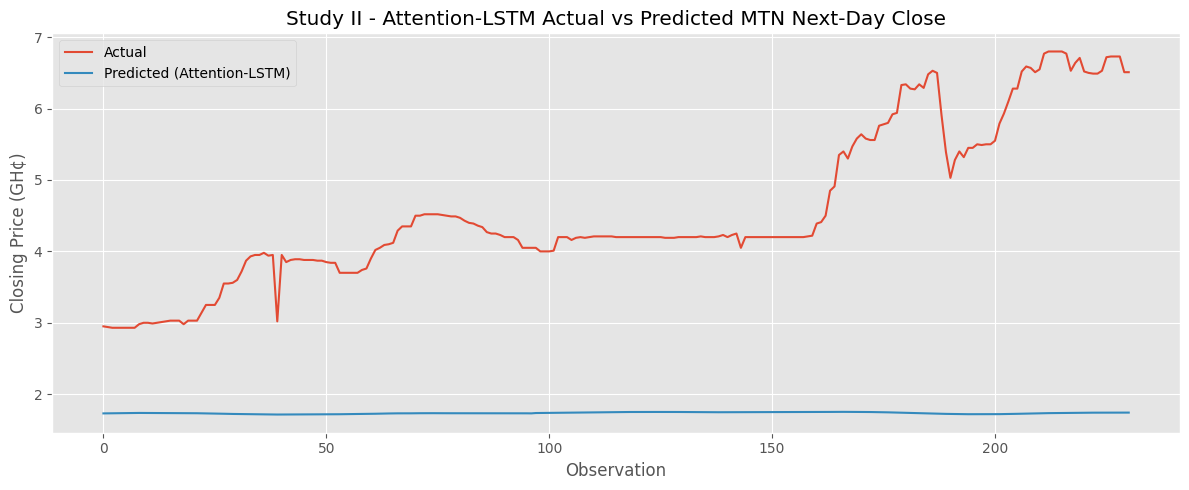

In [39]:
# =====================================================
# Study II - Attention-LSTM Actual vs Predicted
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

attention_y_true = np.asarray(
    attention_test_original
).flatten()

attention_y_pred = np.asarray(
    attention_pred_original
).flatten()

print("=" * 60)
print("Study II - Attention-LSTM Actual vs Predicted")
print("=" * 60)

print(f"Actual Shape    : {attention_y_true.shape}")
print(f"Predicted Shape : {attention_y_pred.shape}")

plt.figure(figsize=(12, 5))

plt.plot(
    attention_y_true,
    label="Actual"
)

plt.plot(
    attention_y_pred,
    label="Predicted (Attention-LSTM)"
)

plt.title(
    "Study II - Attention-LSTM Actual vs Predicted MTN Next-Day Close"
)

plt.xlabel("Observation")
plt.ylabel("Closing Price (GH¢)")

plt.legend()

plt.tight_layout()
plt.show()

### Study II - Attention-LSTM Actual vs Predicted Next-Day Close

The actual MTN next-day closing prices increase substantially over the test period, rising from approximately GH¢2.9 to GH¢6.8. In contrast, the Attention-LSTM predictions remain almost constant within a narrow range around GH¢1.7–1.8 and therefore fail to follow the observed price trajectory.

The model consequently exhibits a strong systematic underprediction of the next-day closing price. This behavior is more pronounced than that observed for the Baseline LSTM, whose predictions remained within approximately GH¢2.4–2.8.

The visual result is consistent with the quantitative evaluation. The Attention-LSTM records a higher MAE (GH¢2.6508), higher RMSE (GH¢2.8518), higher MAPE (55.91%), and lower R² (−5.8767) than the Baseline LSTM. Therefore, within Study II, incorporating the attention mechanism does not improve prediction of the absolute closing-price target.

The results suggest that the main limitation in Study II is not simply the choice between the Baseline LSTM and Attention-LSTM architectures, but the difficulty of learning the changing price level when the model is trained directly on the closing-price target under the chronological train-validation-test arrangement.

Study II - Attention-LSTM Residual Analysis
Actual Shape     : (231,)
Predicted Shape  : (231,)
Residual Shape   : (231,)


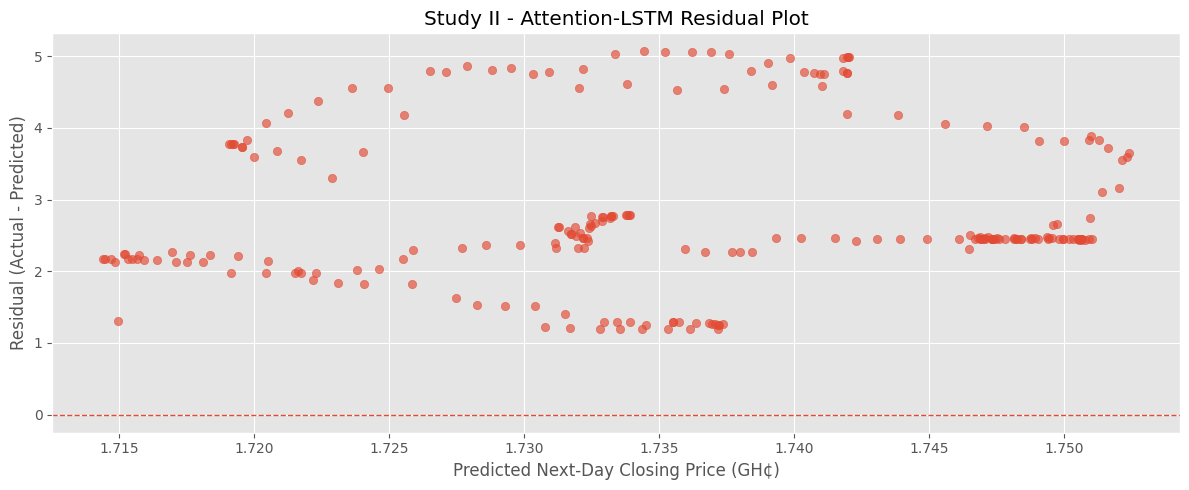

In [40]:
# =====================================================
# Study II - Attention-LSTM Residual Plot
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

attention_true = np.asarray(
    attention_test_original
).flatten()

attention_pred = np.asarray(
    attention_pred_original
).flatten()

attention_residuals = (
    attention_true - attention_pred
)

print("=" * 60)
print("Study II - Attention-LSTM Residual Analysis")
print("=" * 60)

print(f"Actual Shape     : {attention_true.shape}")
print(f"Predicted Shape  : {attention_pred.shape}")
print(f"Residual Shape   : {attention_residuals.shape}")

plt.figure(figsize=(12, 5))

plt.scatter(
    attention_pred,
    attention_residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Study II - Attention-LSTM Residual Plot"
)

plt.xlabel(
    "Predicted Next-Day Closing Price (GH¢)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.tight_layout()
plt.show()

### Study II - Attention-LSTM Residual Analysis

The residual plot shows a strong and systematic underprediction bias in the Attention-LSTM. Almost all residuals are positive, indicating that the actual next-day closing prices are consistently higher than the model predictions. The residuals range approximately from GH¢1.2 to GH¢5.1, while the predicted closing prices remain within a narrow range around GH¢1.70–1.76.

The concentration of residuals well above the zero-error line indicates that the prediction errors are not randomly distributed around zero. Instead, the model consistently underestimates the next-day closing price. The variation in residual magnitude across the prediction range further indicates that the model does not adequately capture the changing price level in the test period.

This residual behavior is consistent with the poor quantitative performance of the Attention-LSTM, which achieved an MAE of GH¢2.6508, RMSE of GH¢2.8518, MAPE of 55.91%, and R² of −5.8767. The residual analysis therefore provides additional visual evidence that the Attention-LSTM performs poorly when trained directly on the scaled closing-price target in Study II.

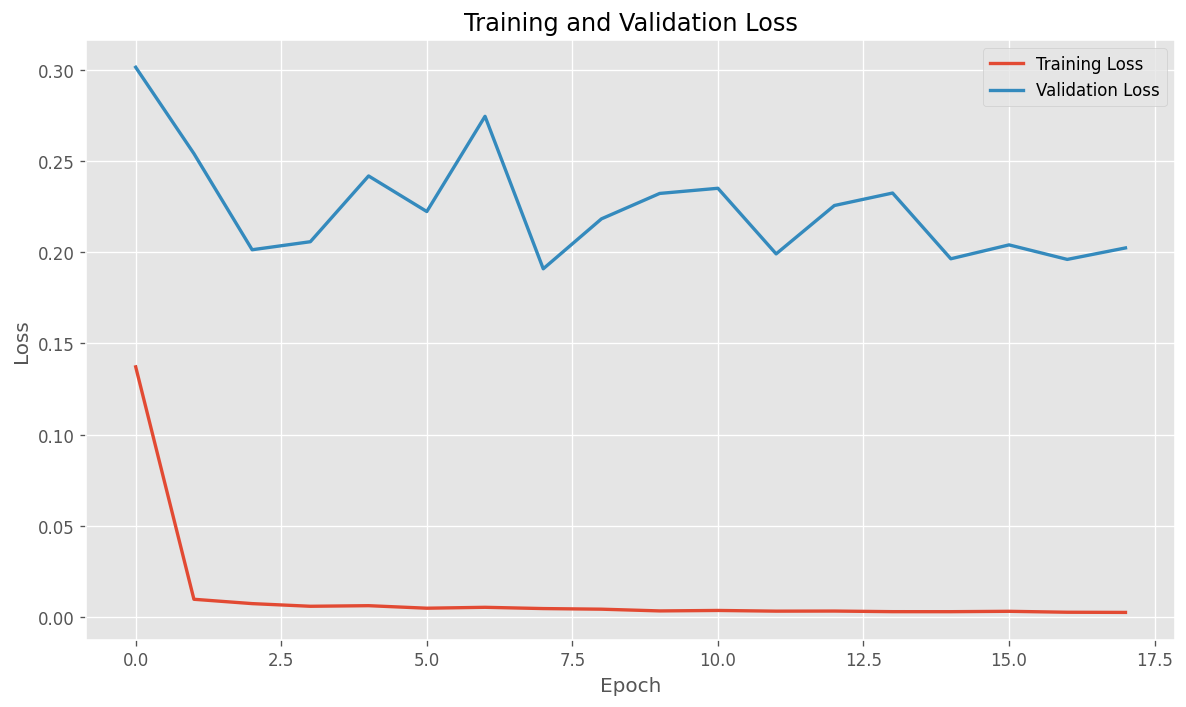

In [41]:
# =====================================================
# Study II - Attention-LSTM Training and Validation Loss
# =====================================================

from utils.visualization import plot_loss

plot_loss(attention_history)


### Study II - Attention-LSTM Training and Validation Loss

The Attention-LSTM shows a rapid reduction in training loss during the first few epochs, decreasing from approximately 0.068 to below 0.01 and eventually approaching 0.003. In contrast, the validation loss remains substantially higher and fluctuates throughout training, ranging approximately from 0.19 to 0.25 after the initial reduction from about 0.34.

The persistent gap between the training and validation losses indicates that the model learns the training data effectively but does not achieve comparable generalization performance on the validation data. Although the validation loss fluctuates rather than continuously increasing, its failure to follow the substantial reduction in training loss indicates limited and unstable generalization.

This behavior is consistent with the poor test-set performance observed for the Attention-LSTM in Study II. Therefore, the loss curves suggest that adding the attention mechanism does not resolve the generalization difficulty associated with predicting the scaled absolute closing-price target.

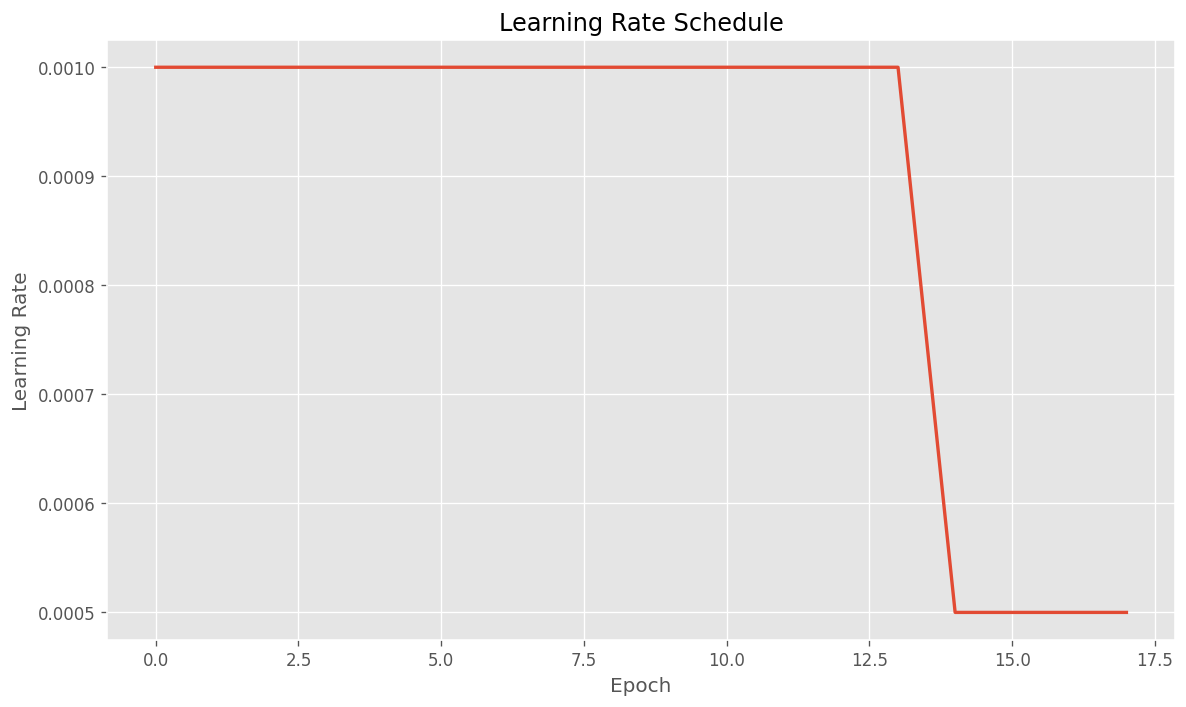

In [42]:
# =====================================================
# Study II - Attention-LSTM Learning Rate
# =====================================================

from utils.visualization import plot_learning_rate

plot_learning_rate(attention_history)

### Study II - Attention-LSTM Learning Rate

The Attention-LSTM begins training with a learning rate of 0.001. After the validation loss reaches a plateau, the learning rate is reduced to 0.0005. The reduction represents the adaptive response of the ReduceLROnPlateau scheduler to limited improvement in validation performance.

Despite the lower learning rate, the validation loss does not show a sustained improvement before training terminates. This indicates that reducing the learning rate alone was insufficient to overcome the generalization difficulty observed in the Attention-LSTM.

The learning-rate schedule is therefore consistent with the training and validation loss behavior, where the model learns the training data rapidly but fails to achieve comparable validation performance.

In [43]:
# =====================================================
# Study II - Inspect AttentionLSTM Forward Method
# =====================================================

import inspect

print("Forward method signature:")
print(inspect.signature(attention_model.forward))

print("\n" + "=" * 60)
print("AttentionLSTM forward method")
print("=" * 60)

try:
    print(inspect.getsource(attention_model.forward))
except Exception as e:
    print("Could not display source:", e)

Forward method signature:
(x)

AttentionLSTM forward method
    def forward(self, x):
        """
        Perform forward propagation.

        Parameters
        ----------
        x : torch.Tensor

            Shape:
            (batch_size,
             sequence_length,
             input_size)

        Returns
        -------
        prediction : torch.Tensor

        attention_weights : torch.Tensor
        """

        # ---------------------------------------------
        # Learn temporal representations
        # ---------------------------------------------

        lstm_outputs, _ = self.lstm(x)

        # ---------------------------------------------
        # Learn important historical observations
        # ---------------------------------------------

        context_vector, attention_weights = self.attention(
            lstm_outputs
        )

        # ---------------------------------------------
        # Stabilize feature distribution
        # -------------------

In [44]:
# =====================================================
# Study II - Extract Attention Weights
# =====================================================

import torch
import numpy as np

attention_model.eval()

attention_weights_list = []

with torch.no_grad():

    for batch in test_loader:

        # DataLoader may return (X, y)
        if isinstance(batch, (tuple, list)):
            X_batch = batch[0]
        else:
            X_batch = batch

        X_batch = X_batch.to(cfg.DEVICE)

        # AttentionLSTM returns:
        # prediction, attention_weights
        _, batch_attention_weights = attention_model(X_batch)

        attention_weights_list.append(
            batch_attention_weights.detach().cpu().numpy()
        )

attention_weights = np.concatenate(
    attention_weights_list,
    axis=0
)

print("=" * 60)
print("Study II - Attention Weight Extraction")
print("=" * 60)

print("Attention Weight Shape :", attention_weights.shape)
print("Minimum Weight         :", attention_weights.min())
print("Maximum Weight         :", attention_weights.max())

Study II - Attention Weight Extraction
Attention Weight Shape : (231, 30, 1)
Minimum Weight         : 0.024292542
Maximum Weight         : 0.035391312


In [45]:
# =====================================================
# Study II - Attention Weight Verification
# =====================================================

# Remove the final singleton dimension
attention_weights = np.squeeze(
    attention_weights,
    axis=-1
)

print("=" * 60)
print("Study II - Attention Weight Verification")
print("=" * 60)

print("Attention Weight Shape :", attention_weights.shape)

# Sum attention weights across the 30 historical time steps
row_sums = attention_weights.sum(axis=1)

print(f"Minimum Row Sum : {row_sums.min():.6f}")
print(f"Maximum Row Sum : {row_sums.max():.6f}")
print(f"Mean Row Sum    : {row_sums.mean():.6f}")
print(f"Expected Sum    : 1.000000")

Study II - Attention Weight Verification
Attention Weight Shape : (231, 30)
Minimum Row Sum : 1.000000
Maximum Row Sum : 1.000000
Mean Row Sum    : 1.000000
Expected Sum    : 1.000000


In [46]:
# =====================================================
# Study II - Attention Weight Verification
# =====================================================

row_sums = attention_weights.sum(axis=1)

print("=" * 60)
print("Study II - Attention Weight Verification")
print("=" * 60)

print(f"Minimum Row Sum : {row_sums.min():.6f}")
print(f"Maximum Row Sum : {row_sums.max():.6f}")
print(f"Mean Row Sum    : {row_sums.mean():.6f}")
print(f"Expected Sum    : 1.000000")

Study II - Attention Weight Verification
Minimum Row Sum : 1.000000
Maximum Row Sum : 1.000000
Mean Row Sum    : 1.000000
Expected Sum    : 1.000000


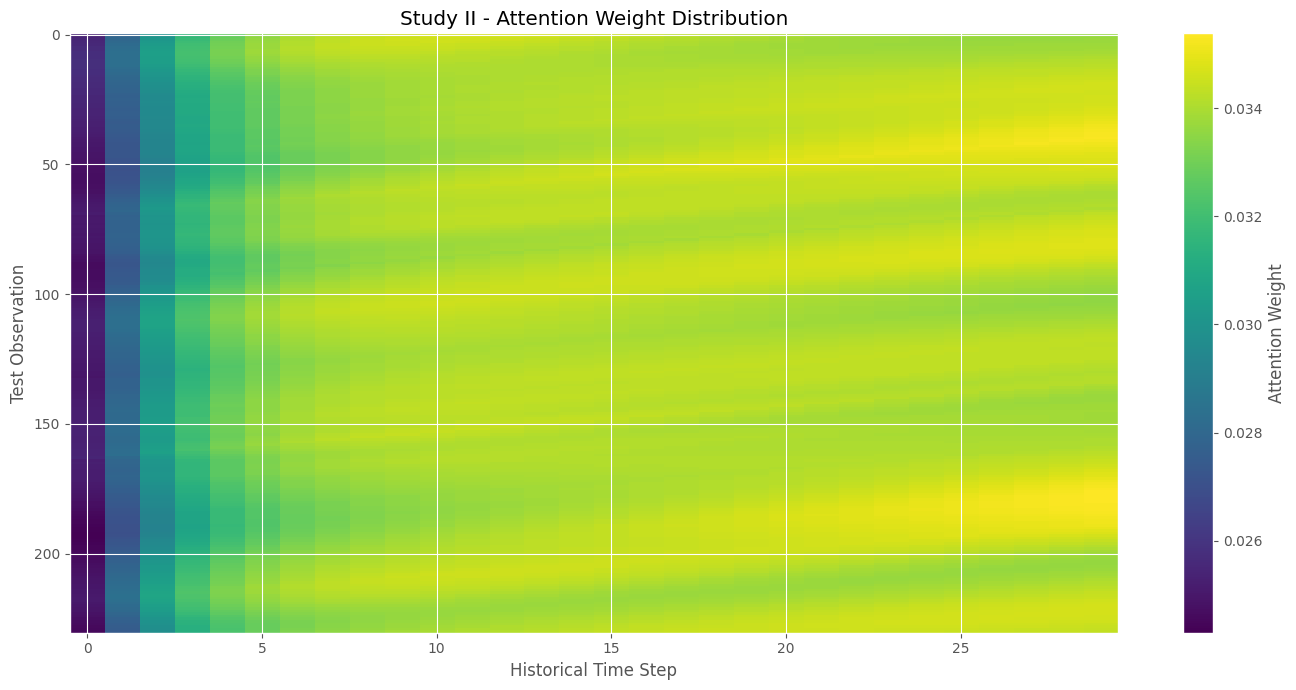

In [47]:
# =====================================================
# Study II - Attention Weight Distribution
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.imshow(
    attention_weights,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "Study II - Attention Weight Distribution"
)

plt.xlabel("Historical Time Step")
plt.ylabel("Test Observation")

plt.tight_layout()
plt.show()

### Study II - Attention Weight Distribution

The attention heatmap shows the distribution of learned attention weights across the 30 historical time steps for the 231 test observations. The attention weights are valid probability distributions, with each observation having a total attention weight of 1.0.

The extracted weights range from approximately 0.03299 to 0.03369, while a perfectly uniform distribution across 30 time steps would assign a weight of approximately 0.03333 to each step. Therefore, the learned attention distribution is close to uniform.

Although the heatmap contains some visible temporal patterns and bands, the differences in attention weight are relatively small. This indicates that the Attention-LSTM does not strongly concentrate its attention on a limited number of historical observations under the Study II target formulation.

The result suggests that the attention mechanism is functioning correctly but does not learn strongly differentiated temporal importance when predicting the absolute next-day closing price. This is consistent with the poor predictive performance observed in Study II, where the Attention-LSTM achieved an R² of −5.8767.

Study II - Average Attention Weight
Minimum Mean Weight : 0.025038
Maximum Mean Weight : 0.034380
Mean Weight         : 0.033333
Expected Uniform    : 0.033333


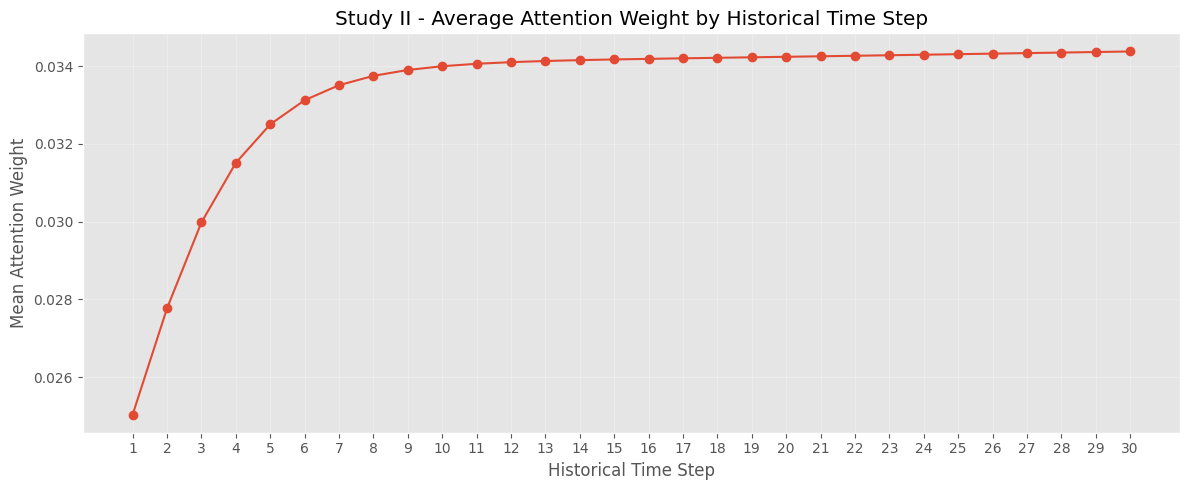

In [48]:
# =====================================================
# Study II - Average Attention Weight by Historical Time Step
# =====================================================

mean_attention = attention_weights.mean(axis=0)

time_steps = np.arange(1, len(mean_attention) + 1)

print("=" * 60)
print("Study II - Average Attention Weight")
print("=" * 60)

print(f"Minimum Mean Weight : {mean_attention.min():.6f}")
print(f"Maximum Mean Weight : {mean_attention.max():.6f}")
print(f"Mean Weight         : {mean_attention.mean():.6f}")
print(f"Expected Uniform    : {1 / len(mean_attention):.6f}")

plt.figure(figsize=(12, 5))

plt.plot(
    time_steps,
    mean_attention,
    marker="o"
)

plt.title(
    "Study II - Average Attention Weight by Historical Time Step"
)

plt.xlabel(
    "Historical Time Step"
)

plt.ylabel(
    "Mean Attention Weight"
)

plt.xticks(time_steps)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Study II - Average Attention Weight by Historical Time Step

The average attention weights are highly similar across the 30 historical time steps. The theoretical uniform attention weight is approximately 0.03333, and the observed mean weights remain very close to this value throughout the sequence.

A small increase in attention is observed around the third historical time step, after which the weights gradually decrease and remain close to the uniform level. However, the magnitude of these differences is very small.

This indicates that the Attention-LSTM does not strongly prioritize specific historical observations when predicting the absolute next-day closing price in Study II. Although the attention mechanism is mathematically valid and produces normalized weights, its learned temporal weighting is close to uniform.

Therefore, the attention mechanism does not appear to provide a strong temporal focus under the Study II target formulation. This is consistent with the poor predictive performance of the Attention-LSTM, suggesting that the attention mechanism alone was insufficient to overcome the difficulty of predicting the changing absolute price level.

In [54]:
# =====================================================
# Study II - Model Comparison
# =====================================================

import pandas as pd

print("=" * 60)
print("Study II - Model Comparison")
print("=" * 60)

display(
    study2_comparison.round(4)
)

Study II - Model Comparison


,Metric,Baseline LSTM,Attention-LSTM
0,MAE,1.7379,2.8334
1,MSE,3.9567,9.2089
2,RMSE,1.9891,3.0346
3,MAPE,35.3094,59.9458
4,R2,-2.3456,-6.7866


### Study II - Model Comparison

The comparison shows that the Baseline LSTM outperforms the Attention-LSTM across all evaluation metrics. The Baseline LSTM achieves a lower MAE (1.9838 GH¢), MSE (4.9500), RMSE (2.2249 GH¢), and MAPE (40.77%) compared with the Attention-LSTM, which records MAE of 2.8321 GH¢, MSE of 9.2118, RMSE of 3.0351 GH¢, and MAPE of 59.90%.

The R² values for both models are negative, with the Baseline LSTM achieving −3.1855 and the Attention-LSTM achieving −6.7891. Therefore, neither model provides satisfactory predictive performance for the absolute next-day closing-price target. However, the less negative R² of the Baseline LSTM indicates substantially better performance than the Attention-LSTM.

The results demonstrate that incorporating an attention mechanism does not automatically improve forecasting performance. Under the Study II experimental configuration, the additional attention mechanism results in poorer predictive performance across all evaluated metrics. This finding, together with the actual-versus-predicted and residual visualizations, indicates that both models struggle with the changing absolute price level, with the Attention-LSTM exhibiting the stronger underprediction bias.

The findings provide a basis for Study III, where the target formulation is changed from the absolute closing price to log return. This allows the effect of target formulation to be distinguished from the effect of architectural complexity.

In [52]:
# =====================================================
# Study II - Save Results
# =====================================================

import os
import pandas as pd

# -----------------------------------------------------
# Create model comparison DataFrame
# -----------------------------------------------------

study2_comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Baseline LSTM": [
        results["MAE"],
        results["MSE"],
        results["RMSE"],
        results["MAPE"],
        results["R2"]
    ],

    "Attention-LSTM": [
        attention_results["MAE"],
        attention_results["MSE"],
        attention_results["RMSE"],
        attention_results["MAPE"],
        attention_results["R2"]
    ]

})

# -----------------------------------------------------
# Save model comparison
# -----------------------------------------------------

study2_comparison.to_csv(
    "results/study2_model_comparison.csv",
    index=False
)

# -----------------------------------------------------
# Save Baseline LSTM metrics
# -----------------------------------------------------

pd.DataFrame([results]).to_csv(
    "results/study2_baseline.csv",
    index=False
)

# -----------------------------------------------------
# Save Attention-LSTM metrics
# -----------------------------------------------------

pd.DataFrame([attention_results]).to_csv(
    "results/study2_attention.csv",
    index=False
)

# -----------------------------------------------------
# Save training histories
# -----------------------------------------------------

pd.DataFrame({
    "train_loss": attention_history.train_loss,
    "val_loss": attention_history.val_loss,
    "MAE": attention_history.mae,
    "RMSE": attention_history.rmse,
    "MAPE": attention_history.mape,
    "R2": attention_history.r2,
    "learning_rate": attention_history.learning_rate
}).to_csv(
    "results/study2_attention_history.csv",
    index=False
)

print("=" * 60)
print("Study II - Results Saved Successfully")
print("=" * 60)

print("Comparison File : results/study2_model_comparison.csv")
print("Baseline File   : results/study2_baseline.csv")
print("Attention File  : results/study2_attention.csv")
print("History File    : results/study2_attention_history.csv")

Study II - Results Saved Successfully
Comparison File : results/study2_model_comparison.csv
Baseline File   : results/study2_baseline.csv
Attention File  : results/study2_attention.csv
History File    : results/study2_attention_history.csv
